# Electronic Component Compliance Risk Assessment — RoHS × REACH
### Rule-Based Compliance Risk Scoring, per the `Parts_Compliance_.xlsx` Workbook's Own Declared Methodology

**Scope of this notebook:** this model scores every part in `Parts_Compliance` on regulatory
compliance risk, using the same rule-based approach as `Parts_Risk_Assessment.ipynb` (normalize →
weight → composite score → hard-stop override → sensitivity check), but adapted to this workbook's
own **`Scoring_Methodology`** sheet, which is the source of truth for weights and status→score
mappings here — not a separate AHP judgment set.

## Why this isn't a straight copy of the Parts-risk equation

The Parts-risk notebook built an AHP-weighted Likelihood × Impact model across 10 factors it
verified were populated. This workbook's `Scoring_Methodology` sheet *declares* 5 compliance
categories — RoHS, REACH, Conflict Minerals, PFAS, CA Prop 65 — each with a weight and a
status→score table already spelled out by whoever built the workbook. That's a genuinely different
starting point, so before writing any formula this notebook first **checks which of those 5
categories actually have populated data in `Parts_Compliance`**, exactly as instructed: verify the
features exist, add value, and are relevant, rather than assuming the declared methodology matches
the delivered data.

**Finding, stated up front:** only 2 of the 5 declared categories — **RoHS** and **REACH** — have a
real, populated column in this file. Conflict Minerals, PFAS, and CA Prop 65 are declared in the
methodology and have score-mapping tables ready, but **no corresponding column exists anywhere in
`Parts_Compliance`** — the `Data_Sourcing_Guide` sheet confirms this is intentional (CMRT/manufacturer
RFI work not yet done), not a data-export error. Scoring a category that's 100% absent would mean
assigning every part the same constant "Unknown" value — zero variance, zero discriminating power,
and false precision (implying 5-factor coverage when only 2 factors are real). So this notebook
builds the composite score from the 2 verified categories only, renormalizes their declared weights
to sum to 1, and documents the exclusion instead of quietly padding the score.

## Methodology

1. **Parse the workbook's own `Scoring_Methodology` sheet programmatically** — weights and
   status→score mappings are read from the sheet itself, not hardcoded, so this notebook stays in
   sync if the yellow cells are edited (the sheet's own stated design intent).
2. **Feature verification** — cross-check the 5 declared categories against the actual columns in
   `Parts_Compliance` before using any of them.
3. **Composite formula**, exactly as declared in the sheet:
   $$\text{Compliance Score} = \frac{\sum (\text{category weight} \times \text{category score})}{\sum \text{weights (usable categories only)}}$$
4. **A regulatory hard-stop rule**: any part with `RoHS Status = Non-Compliant` is force-classified
   **High Risk** regardless of its blended score. RoHS is a legal EU/UK/China/CA market-access
   blocker per the sheet's own rationale column — this mirrors the DMSMS hard-stop pattern in the
   Parts-risk notebook (a hard legal/technical fact shouldn't be averaged away by an unrelated
   factor looking fine).
5. **Sensitivity analysis** on the RoHS/REACH weight split (perturbation, not full AHP — with only
   2 factors a 2×2 pairwise matrix has no meaningful Consistency Ratio to check).
6. **Validation** via crosstab against the raw status fields, since with only 2 categorical factors
   (3–4 levels each) unsupervised clustering has too few distinct combinations to add anything a
   crosstab doesn't already show.
7. **Export** a scored table, in the same style as `Parts_Risk_Scored.xlsx`.


In [1]:
# CELL 1: Imports & Setup
print("=" * 80)
print("ELECTRONIC COMPONENT COMPLIANCE RISK ASSESSMENT -- RoHS x REACH")
print("=" * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

print("\n✅ Libraries loaded.")


ELECTRONIC COMPONENT COMPLIANCE RISK ASSESSMENT -- RoHS x REACH

✅ Libraries loaded.


In [2]:
# CELL 2: Load Data -- all three sheets of the compliance workbook
SRC_FILE = 'Parts_Compliance_.xlsx'

def load_excel_sheets(path):
    try:
        return pd.ExcelFile(path)
    except FileNotFoundError:
        return pd.ExcelFile(f"/content/{path}")

xl = load_excel_sheets(SRC_FILE)
print("Sheets found:", xl.sheet_names)

df   = xl.parse('Parts_Compliance')
meth = xl.parse('Scoring_Methodology', header=None)   # keep raw layout -- we parse it below
guide = xl.parse('Data_Sourcing_Guide', header=None)

print(f"\nParts_Compliance: {df.shape[0]} rows, {df.shape[1]} cols")
print(df.dtypes)


Sheets found: ['Parts_Compliance', 'Scoring_Methodology', 'Data_Sourcing_Guide']

Parts_Compliance: 434 rows, 6 cols
ID                  float64
Mfr Part #           object
Description          object
RoHS Status          object
RoHS Source/Note     object
REACH Status         object
dtype: object


## 1. Exploratory Data Analysis

In [3]:
# CELL 3: Structural EDA -- dtypes & missingness
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("Missing values per column:")
print(miss.to_frame('n_missing') if len(miss) else "No missing values.")

print("\nDuplicate 'Mfr Part #' rows:", df['Mfr Part #'].duplicated().sum())


Missing values per column:
              n_missing
ID                    1
Mfr Part #            1
Description           1
RoHS Status           1
REACH Status          1

Duplicate 'Mfr Part #' rows: 0


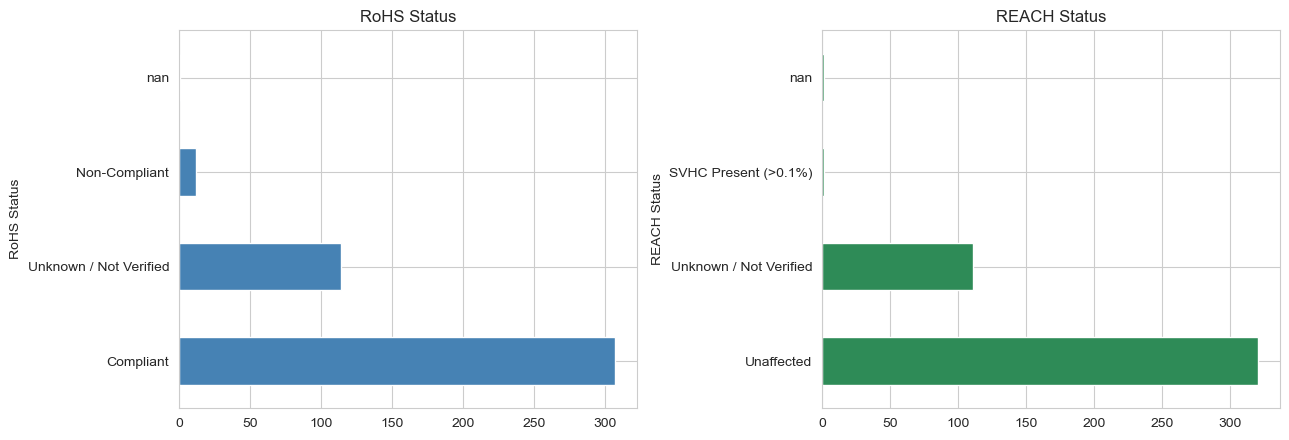

RoHS Status
Compliant                 307
Unknown / Not Verified    114
Non-Compliant              12
NaN                         1
Name: count, dtype: int64

REACH Status
Unaffected                321
Unknown / Not Verified    111
SVHC Present (>0.1%)        1
NaN                         1
Name: count, dtype: int64


In [4]:
# CELL 4: Key-field distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df['RoHS Status'].value_counts(dropna=False).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('RoHS Status')
df['REACH Status'].value_counts(dropna=False).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('REACH Status')
plt.tight_layout(); plt.show()

print(df['RoHS Status'].value_counts(dropna=False))
print()
print(df['REACH Status'].value_counts(dropna=False))


## 2. Feature Verification — Does the Declared Methodology Match the Delivered Data?

The `Scoring_Methodology` sheet declares 5 compliance categories with weights and full
status→score mapping tables. Before building any equation on top of them, each declared category
is checked against the actual `Parts_Compliance` columns. A category that has a weight and a
mapping table but **no populated column anywhere in the data** would only be scoreable as a
constant "Unknown" value for every single part — that adds no discriminating information and
falsely implies 5-factor coverage, so it's excluded rather than silently padded in.

In [5]:
# CELL 5: Parse the workbook's own Scoring_Methodology sheet (source of truth, not hardcoded)

# -- 1. Category weights table --
w_start = meth[meth[1] == 'Category'].index[0] + 1
w_rows = []
r = w_start
while pd.notna(meth.loc[r, 1]) and meth.loc[r, 1] != 'Total':
    w_rows.append((meth.loc[r, 1], float(meth.loc[r, 2])))
    r += 1
weights_declared = dict(w_rows)
print("Declared category weights (from the workbook's yellow cells):")
for k, v in weights_declared.items():
    print(f"  {k:26s} {v:.2f}")

# -- 2. Status -> score mapping table --
m_start = meth[meth[2] == 'Status Text (must match dropdown exactly)'].index[0] + 1
map_rows = []
r = m_start
while r < len(meth) and pd.notna(meth.loc[r, 1]):
    map_rows.append((meth.loc[r, 1], meth.loc[r, 2], float(meth.loc[r, 3])))
    r += 1
score_map_df = pd.DataFrame(map_rows, columns=['Category', 'Status', 'Score'])
print(f"\nParsed {len(score_map_df)} status->score rows across {score_map_df['Category'].nunique()} categories.")


Declared category weights (from the workbook's yellow cells):
  RoHS                       0.30
  REACH (SVHC)               0.25
  Conflict Minerals (3TG)    0.20
  PFAS                       0.15
  CA Prop 65                 0.10

Parsed 17 status->score rows across 5 categories.


In [6]:
# CELL 6: Cross-check declared categories against actual Parts_Compliance columns
col_map = {
    'RoHS':               'RoHS Status',
    'REACH':               'REACH Status',
    'Conflict Minerals':   None,   # declared in Scoring_Methodology, no column in Parts_Compliance
    'PFAS':                None,   # same
    'Prop 65':             None,   # same
}
declared_categories = ['RoHS', 'REACH', 'Conflict Minerals', 'PFAS', 'Prop 65']

print(f"{'Category':22s} {'Column in Parts_Compliance':30s} {'Usable?'}")
print("-" * 70)
for cat in declared_categories:
    col = col_map.get(cat)
    present = (col is not None) and (col in df.columns)
    print(f"{cat:22s} {str(col):30s} {'YES' if present else 'NO -- excluded'}")

USABLE = [c for c in declared_categories if col_map.get(c) and col_map[c] in df.columns]
EXCLUDED = [c for c in declared_categories if c not in USABLE]

print(f"\nUsable categories (real, populated data): {USABLE}")
print(f"Excluded (declared in methodology, but no data column present): {EXCLUDED}")
print("\nPer Data_Sourcing_Guide: Conflict Minerals needs per-manufacturer CMRT lookups (~31 lookups,")
print("not 434), PFAS is genuinely undocumented for most legacy parts, and Prop 65 needs manufacturer")
print("SDS/RFI. None of these are in this data export -- this is a scope gap to close later, not a")
print("bug to paper over now.")


Category               Column in Parts_Compliance     Usable?
----------------------------------------------------------------------
RoHS                   RoHS Status                    YES
REACH                  REACH Status                   YES
Conflict Minerals      None                           NO -- excluded
PFAS                   None                           NO -- excluded
Prop 65                None                           NO -- excluded

Usable categories (real, populated data): ['RoHS', 'REACH']
Excluded (declared in methodology, but no data column present): ['Conflict Minerals', 'PFAS', 'Prop 65']

Per Data_Sourcing_Guide: Conflict Minerals needs per-manufacturer CMRT lookups (~31 lookups,
not 434), PFAS is genuinely undocumented for most legacy parts, and Prop 65 needs manufacturer
SDS/RFI. None of these are in this data export -- this is a scope gap to close later, not a
bug to paper over now.


## 3. Data Cleaning

In [7]:
# CELL 7: Standardize keys, drop the unpopulated template row
df['Mfr Part #'] = df['Mfr Part #'].astype(str).str.strip().str.upper()

empty_row = df['RoHS Status'].isna() & df['REACH Status'].isna()
print(f"Fully-empty template/example rows: {empty_row.sum()}")
df = df[~empty_row].reset_index(drop=True)
print(f"Rows after removing unpopulated template row: {len(df)}")

# Any remaining partial nulls in the usable columns are genuinely "Unknown / Not Verified"
df['RoHS Status']  = df['RoHS Status'].fillna('Unknown / Not Verified')
df['REACH Status'] = df['REACH Status'].fillna('Unknown / Not Verified')

# Data-quality check: does every status value present in the data actually appear in the
# workbook's own mapping table? (catches typos / dropdown drift before scoring)
unmapped_rohs  = set(df['RoHS Status'])  - set(score_map_df.loc[score_map_df.Category == 'RoHS', 'Status'])
unmapped_reach = set(df['REACH Status']) - set(score_map_df.loc[score_map_df.Category == 'REACH', 'Status'])
print(f"\nUnmapped RoHS status values (should be empty):  {unmapped_rohs}")
print(f"Unmapped REACH status values (should be empty): {unmapped_reach}")


Fully-empty template/example rows: 1
Rows after removing unpopulated template row: 433

Unmapped RoHS status values (should be empty):  set()
Unmapped REACH status values (should be empty): set()


## 4. Category Scoring & Weight Renormalization

`N_RHS` and `N_RCH` are the two usable, verified compliance signals, each scored 0–100 via the
workbook's own status→score table (already 0–100, so no additional normalization step is needed —
unlike the Parts-risk notebook's raw features, these arrive pre-scaled by the workbook's design).

Per the workbook's own formula — *"Compliance Score = Σ(category weight × category score) ÷
Σ(weights)"* — the denominator already normalizes by whichever weights are actually summed. Since
only RoHS (0.30) and REACH (0.25) are usable, their weights are renormalized to sum to 1 rather
than silently keeping the original 0.55 total (which would understate every part's score against
the sheet's own 0–100 scale and 60/85 tier thresholds).

In [8]:
# CELL 8: Score each usable category, renormalize weights, compute composite
def lookup_score(cat, status):
    m = score_map_df[(score_map_df['Category'] == cat) & (score_map_df['Status'] == status)]
    return m['Score'].iloc[0] if len(m) else 50.0  # unmapped/blank treated as Unknown

df['N_RHS'] = df['RoHS Status'].apply(lambda s: lookup_score('RoHS', s))     # RoHS score, 0-100
df['N_RCH'] = df['REACH Status'].apply(lambda s: lookup_score('REACH', s))   # REACH score, 0-100

w_rohs_raw  = weights_declared['RoHS']
w_reach_raw = weights_declared['REACH (SVHC)']
w_total     = w_rohs_raw + w_reach_raw
w_rohs      = w_rohs_raw  / w_total
w_reach     = w_reach_raw / w_total
print(f"Original declared weights: RoHS={w_rohs_raw}, REACH={w_reach_raw}  (sum={w_total}, "
      f"the other {1-w_total:.2f} belongs to the 3 excluded categories)")
print(f"Renormalized over usable categories: RoHS={w_rohs:.4f}, REACH={w_reach:.4f}")

df['Compliance_Score'] = w_rohs * df['N_RHS'] + w_reach * df['N_RCH']
print(f"\nCompliance_Score summary:\n{df['Compliance_Score'].describe().round(2)}")


Original declared weights: RoHS=0.3, REACH=0.25  (sum=0.55, the other 0.45 belongs to the 3 excluded categories)
Renormalized over usable categories: RoHS=0.5455, REACH=0.4545

Compliance_Score summary:
count    433.00
mean      85.42
std       22.01
min       22.73
25%       72.73
50%      100.00
75%      100.00
max      100.00
Name: Compliance_Score, dtype: float64


## 5. Risk Classification, With a Regulatory Hard-Stop Rule

Risk tiers follow the workbook's own declared thresholds: **≥85 Low Risk · 60–84 Medium Risk · <60
High Risk**.

**Hard-stop rule (new for this equation, matching the DMSMS hard-stop pattern in the Parts-risk
notebook):** any part with `RoHS Status = Non-Compliant` is force-classified **High Risk**,
regardless of its blended score. RoHS non-compliance is a *legal market-access blocker* into
EU/UK/China/CA per the workbook's own rationale column — a hard regulatory fact, not something a
merely-fine REACH score should be allowed to average up and out of the High-Risk bucket.

A `Compliance_Risk_Score = 100 - Compliance_Score` column is also added so this table can sit
alongside `Parts_Risk_Scored.xlsx` on the same "higher = riskier" convention used there, for
eventual blending into one overall supply-chain risk view.

In [9]:
# CELL 9: Classify risk tier and apply the RoHS hard-stop override
def tier(score):
    if score >= 85: return 'Low Risk', 1
    if score >= 60: return 'Medium Risk', 3
    return 'High Risk', 5

classified = df['Compliance_Score'].apply(tier)
df['Compliance_Risk_Tier']  = classified.apply(lambda x: x[0])
df['Compliance_Risk_Level'] = classified.apply(lambda x: x[1])

n_before = (df['Compliance_Risk_Tier'] == 'High Risk').sum()
df['hard_stop_flag'] = df['RoHS Status'] == 'Non-Compliant'
df.loc[df['hard_stop_flag'], 'Compliance_Risk_Tier']  = 'High Risk'
df.loc[df['hard_stop_flag'], 'Compliance_Risk_Level'] = 5
n_after = (df['Compliance_Risk_Tier'] == 'High Risk').sum()

df['Compliance_Risk_Score'] = 100 - df['Compliance_Score']

print(f"Parts triggering the RoHS hard-stop (legal non-compliance): {df['hard_stop_flag'].sum()}")
print(f"High Risk count before override: {n_before}  ->  after override: {n_after}")

order = ['Low Risk', 'Medium Risk', 'High Risk']
print()
print(df['Compliance_Risk_Tier'].value_counts().reindex(order, fill_value=0))


Parts triggering the RoHS hard-stop (legal non-compliance): 12
High Risk count before override: 105  ->  after override: 105

Compliance_Risk_Tier
Low Risk       291
Medium Risk     37
High Risk      105
Name: count, dtype: int64


## 6. Sensitivity Analysis — RoHS/REACH Weight Split

With only 2 factors, a full AHP pairwise-comparison matrix has no meaningful Consistency Ratio (a
2×2 reciprocal matrix is consistent by construction), so a direct weight-perturbation sweep is used
instead: the raw declared weights (0.30 / 0.25) are randomly perturbed (×0.75–×1.33) across 300
trials, renormalized, and each part's tier stability is tracked — the same spirit as the Parts-risk
notebook's Monte Carlo step, scaled to a 2-factor problem.

Because both inputs here are categorical (3–4 discrete status levels each, not continuous
measurements), expect the result to be more bimodal than the Parts-risk notebook's smoother
sensitivity curve — that's a property of the data, not a modeling shortcut.

In [10]:
# CELL 10: Weight-perturbation sensitivity analysis
n_trials = 300
not_low_hits = np.zeros(len(df))
rohs_scores  = df['N_RHS'].values
reach_scores = df['N_RCH'].values

for _ in range(n_trials):
    pr_w = w_rohs_raw  * np.random.uniform(0.75, 1.33)
    pe_w = w_reach_raw * np.random.uniform(0.75, 1.33)
    s = pr_w + pe_w
    pr, pe = pr_w / s, pe_w / s
    comp = pr * rohs_scores + pe * reach_scores
    not_low_hits += (comp < 85)

df['pct_trials_not_low_risk'] = not_low_hits / n_trials * 100
df.loc[df['hard_stop_flag'], 'pct_trials_not_low_risk'] = 100.0

robust_risk = (df['pct_trials_not_low_risk'] >= 80).sum()
border      = ((df['pct_trials_not_low_risk'] >= 20) & (df['pct_trials_not_low_risk'] < 80)).sum()
robust_low  = (df['pct_trials_not_low_risk'] < 20).sum()

print(f"Parts robustly NOT Low-Risk across weight choices (>=80% of trials): {robust_risk}")
print(f"Borderline / weight-sensitive parts (20-80% of trials):              {border}")
print(f"Parts robustly Low-Risk regardless of weight choice (<20%):          {robust_low}")
print("\n(Borderline count of 0 is expected here: with 3-4 discrete status levels per factor, there")
print("are only 9-12 possible score combinations, so most trials land the same side of the 85")
print("threshold every time -- unlike the Parts-risk notebook's continuous factors.)")


Parts robustly NOT Low-Risk across weight choices (>=80% of trials): 142
Borderline / weight-sensitive parts (20-80% of trials):              0
Parts robustly Low-Risk regardless of weight choice (<20%):          291

(Borderline count of 0 is expected here: with 3-4 discrete status levels per factor, there
are only 9-12 possible score combinations, so most trials land the same side of the 85
threshold every time -- unlike the Parts-risk notebook's continuous factors.)


## 7. Validation

With only 2 categorical factors (a handful of discrete score combinations total), unsupervised
K-Means clustering — used to validate the Parts-risk notebook's 10-factor AHP categories — would
have too few distinct points to add anything beyond what a direct crosstab already shows. So
validation here is a crosstab of the raw status fields against the final tier, confirming the rule
logic behaves as intended (Non-Compliant always High, Unknown/REACH-affected parts pulled toward
Medium/High, clean Compliant+Unaffected parts Low).

In [11]:
# CELL 11: Crosstab validation
print("RoHS Status x Compliance Risk Tier:")
print(pd.crosstab(df['RoHS Status'], df['Compliance_Risk_Tier']).reindex(columns=order, fill_value=0))

print("\nREACH Status x Compliance Risk Tier:")
print(pd.crosstab(df['REACH Status'], df['Compliance_Risk_Tier']).reindex(columns=order, fill_value=0))


RoHS Status x Compliance Risk Tier:
Compliance_Risk_Tier    Low Risk  Medium Risk  High Risk
RoHS Status                                             
Compliant                    291           16          0
Non-Compliant                  0            0         12
Unknown / Not Verified         0           21         93

REACH Status x Compliance Risk Tier:
Compliance_Risk_Tier    Low Risk  Medium Risk  High Risk
REACH Status                                            
SVHC Present (>0.1%)           0            1          0
Unaffected                   291           21          9
Unknown / Not Verified         0           15         96


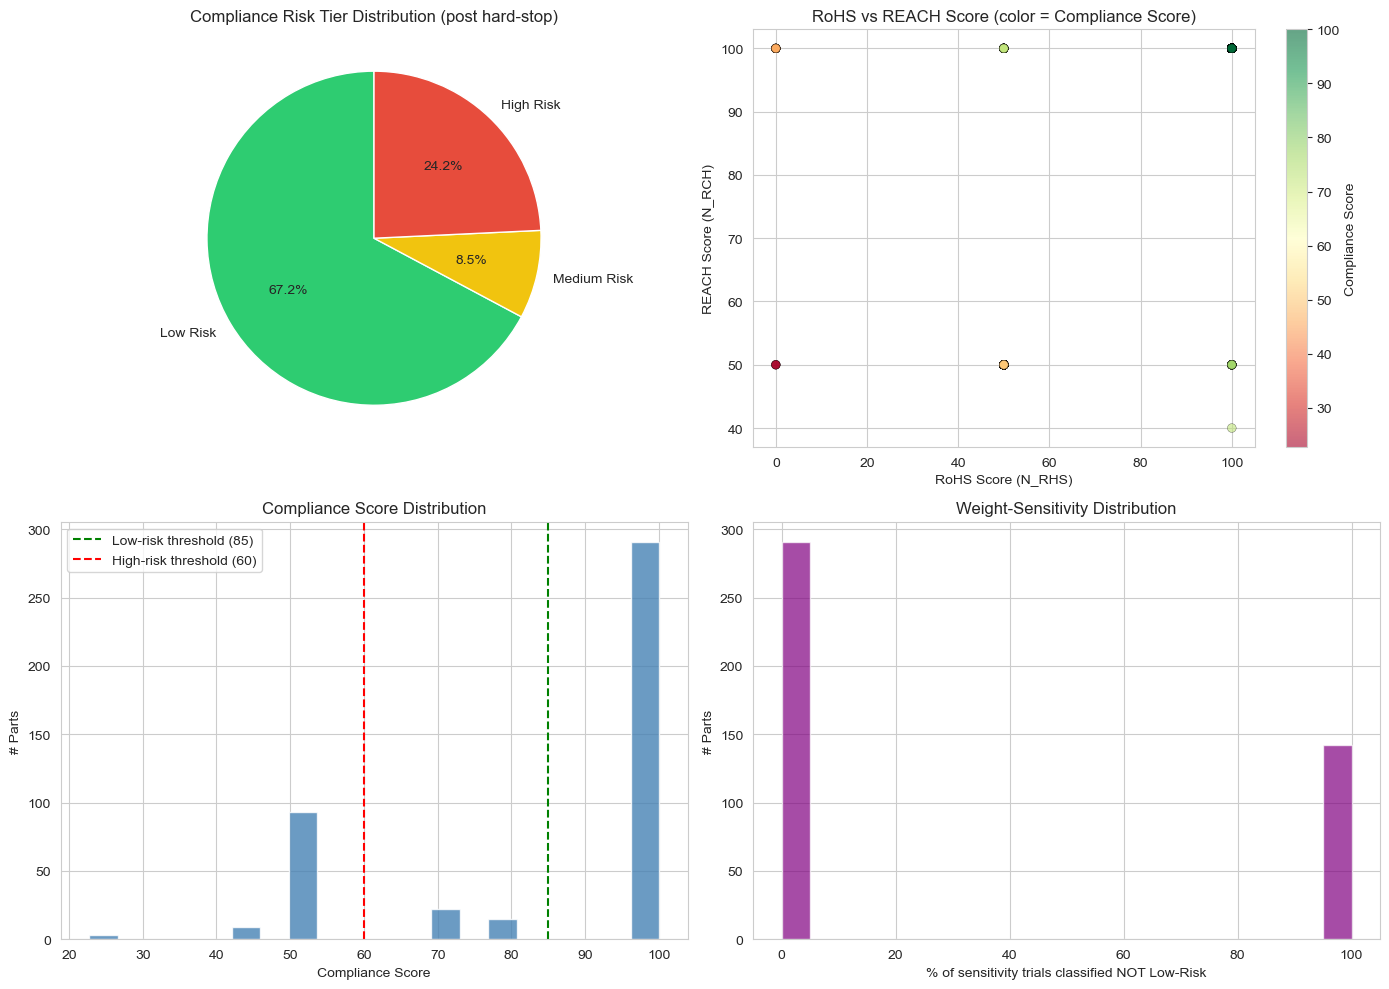

In [12]:
# CELL 12: Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_counts = df['Compliance_Risk_Tier'].value_counts().reindex(order, fill_value=0)
colors = ['#2ecc71', '#f1c40f', '#e74c3c']
axes[0, 0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90)
axes[0, 0].set_title('Compliance Risk Tier Distribution (post hard-stop)')

sc = axes[0, 1].scatter(df['N_RHS'], df['N_RCH'], c=df['Compliance_Score'], cmap='RdYlGn',
                         s=40, alpha=0.6, edgecolors='k', linewidth=0.3)
axes[0, 1].set_xlabel('RoHS Score (N_RHS)'); axes[0, 1].set_ylabel('REACH Score (N_RCH)')
axes[0, 1].set_title('RoHS vs REACH Score (color = Compliance Score)')
plt.colorbar(sc, ax=axes[0, 1], label='Compliance Score')

axes[1, 0].hist(df['Compliance_Score'], bins=20, color='steelblue', alpha=0.8)
axes[1, 0].axvline(85, color='green', ls='--', label='Low-risk threshold (85)')
axes[1, 0].axvline(60, color='red', ls='--', label='High-risk threshold (60)')
axes[1, 0].set_xlabel('Compliance Score'); axes[1, 0].set_ylabel('# Parts')
axes[1, 0].set_title('Compliance Score Distribution')
axes[1, 0].legend()

axes[1, 1].hist(df['pct_trials_not_low_risk'], bins=20, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('% of sensitivity trials classified NOT Low-Risk')
axes[1, 1].set_ylabel('# Parts')
axes[1, 1].set_title('Weight-Sensitivity Distribution')

plt.tight_layout(); plt.show()


## 8. Top-Risk Parts & Drivers

In [13]:
# CELL 13: Highest compliance-risk parts
top_risk = df.sort_values('Compliance_Score').head(25)[
    ['Mfr Part #', 'RoHS Status', 'REACH Status', 'hard_stop_flag',
     'Compliance_Score', 'Compliance_Risk_Tier', 'pct_trials_not_low_risk']
].reset_index(drop=True)
top_risk


,Mfr Part #,RoHS Status,REACH Status,hard_stop_flag,Compliance_Score,Compliance_Risk_Tier,pct_trials_not_low_risk
0,932SV901AKLF,Non-Compliant,Unknown / Not Verified,True,22.727273,High Risk,100.0
1,9DB801BFLF,Non-Compliant,Unknown / Not Verified,True,22.727273,High Risk,100.0
2,842S104EGLF,Non-Compliant,Unknown / Not Verified,True,22.727273,High Risk,100.0
3,ADC081S101CIMFX,Non-Compliant,Unaffected,True,45.454545,High Risk,100.0
4,MPC8270CZQMIBA,Non-Compliant,Unaffected,True,45.454545,High Risk,100.0
5,SA575N,Non-Compliant,Unaffected,True,45.454545,High Risk,100.0
6,ADC0838CIWMX,Non-Compliant,Unaffected,True,45.454545,High Risk,100.0
7,ADC08832IMX,Non-Compliant,Unaffected,True,45.454545,High Risk,100.0
8,JLC1562BF,Non-Compliant,Unaffected,True,45.454545,High Risk,100.0
9,JLC1562BFEL,Non-Compliant,Unaffected,True,45.454545,High Risk,100.0


In [14]:
# CELL 14: What's driving High-Risk classifications?
high_risk = df[df['Compliance_Risk_Tier'] == 'High Risk']
print(f"{len(high_risk)} High Risk parts:")
print(f"  - RoHS hard-stop (legal Non-Compliant):        {high_risk['hard_stop_flag'].sum()}")
print(f"  - RoHS Unknown / Not Verified:                 {(high_risk['RoHS Status']=='Unknown / Not Verified').sum()}")
print(f"  - REACH SVHC Present:                          {(high_risk['REACH Status']=='SVHC Present (>0.1%)').sum()}")
print(f"  - REACH Unknown / Not Verified:                {(high_risk['REACH Status']=='Unknown / Not Verified').sum()}")
print(f"  - Robust across >=80% of sensitivity trials:   {(high_risk['pct_trials_not_low_risk']>=80).sum()}")


105 High Risk parts:
  - RoHS hard-stop (legal Non-Compliant):        12
  - RoHS Unknown / Not Verified:                 93
  - REACH SVHC Present:                          0
  - REACH Unknown / Not Verified:                96
  - Robust across >=80% of sensitivity trials:   105


## 9.5 Industry Validation — How Does This Compare to Commercial Platforms (Z2Data, etc.)?

Checked this design against how commercial component-risk platforms actually structure compliance
scoring, since "does it match what real supply-chain companies use" is a fair question to answer
with evidence, not just assert.

**Z2Data's Part Risk Manager** — one of the larger commercial platforms in this space — publishes
its own factor breakdown: a **Compliance Risk Score** that *"takes into account a part's compliance
with environmental regulations such as RoHS, REACH, China RoHS, and more,"* computed as one of six
independent sub-scores (alongside Obsolescence, Market Availability, Technology Generation,
Multi-Sourcing, and Supplier Financial Health) that roll up into one composite Part Risk Score.

**What matches:**
- Treating **Compliance as its own dedicated score**, separate from obsolescence/lifecycle risk,
  is exactly Z2Data's architecture — not something invented for this notebook. That's the reason
  this workbook is scored on its own here rather than folded into the Parts-risk notebook's
  Likelihood axis.
- RoHS and REACH as the anchor regulatory signals matches Z2Data's own stated compliance factors
  list (*"RoHS, REACH, China RoHS, and more"*) — RoHS/REACH are the correct starting core, not an
  arbitrary subset.
- A weighted-composite-with-hard-stop-override pattern is standard practice across this category of
  tool (Z2Data, Assent, EcoVadis, IntegrityNext all publish some version of it).

**What's still a gap versus the full commercial platforms, honestly stated:**
- Z2Data's own compliance factor list explicitly extends to **China RoHS, UFLPA, TAA, WEEE, and
  270+ regulatory lists** beyond the 5 this workbook declares. This notebook (and the workbook it's
  built from) covers a *subset* of what a full commercial platform tracks — RoHS + REACH here vs.
  a much broader regulatory surface commercially.
- Commercial platforms source live, continuously-updated regulatory data (PCNs, SCIP submissions,
  manufacturer declarations) rather than a point-in-time bulk export. The `RoHS Source/Note` column
  in this data is honest about that limit already (*"DigiKey RoHS Compliance Tool bulk export, Jul
  2026"* — a snapshot, not a live feed).

**Conclusion:** the *structure* of this scoring approach — separate compliance score, RoHS/REACH as
core signals, weighted composite with a legal hard-stop — is not an invented methodology; it matches
how the industry's own commercial tooling is built, at a smaller (but honestly-scoped) regulatory
surface. The gap to close for full parity is breadth of regulations tracked (Conflict Minerals,
PFAS, Prop 65, China RoHS, etc.), not the underlying scoring logic.


## 9. Export Results

In [15]:
# CELL 15: Export scored master table
output_cols = [
    'ID', 'Mfr Part #', 'Description', 'RoHS Status', 'RoHS Source/Note', 'REACH Status',
    'N_RHS', 'N_RCH', 'Compliance_Score', 'Compliance_Risk_Score',
    'hard_stop_flag', 'pct_trials_not_low_risk', 'Compliance_Risk_Tier', 'Compliance_Risk_Level'
]
result = df[output_cols].sort_values('Compliance_Score').reset_index(drop=True)
result.to_excel('Parts_Compliance_Scored.xlsx', index=False)
print(f"Saved {len(result)} scored parts to Parts_Compliance_Scored.xlsx")
result.head(10)


Saved 433 scored parts to Parts_Compliance_Scored.xlsx


,ID,Mfr Part #,Description,RoHS Status,RoHS Source/Note,REACH Status,N_RHS,N_RCH,Compliance_Score,Compliance_Risk_Score,hard_stop_flag,pct_trials_not_low_risk,Compliance_Risk_Tier,Compliance_Risk_Level
0,357.0,932SV901AKLF,CLOCK GENERATORS & SUPPORT PRODU,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unknown / Not Verified,0.0,50.0,22.727273,77.272727,True,100.0,High Risk,5
1,359.0,9DB801BFLF,IC ZD BUFFER PCIE 48BSSOP,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unknown / Not Verified,0.0,50.0,22.727273,77.272727,True,100.0,High Risk,5
2,360.0,842S104EGLF,CLOCK SYNTHESIZER/JITTER CLEANER,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unknown / Not Verified,0.0,50.0,22.727273,77.272727,True,100.0,High Risk,5
3,413.0,ADC081S101CIMFX,IC ADC 8BIT SOT-23-6,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unaffected,0.0,100.0,45.454545,54.545455,True,100.0,High Risk,5
4,141.0,MPC8270CZQMIBA,IC MPU MPC82XX 333MHZ PBGA516,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unaffected,0.0,100.0,45.454545,54.545455,True,100.0,High Risk,5
5,242.0,SA575N,IC COMPANDOR 2CH 20PDIP,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unaffected,0.0,100.0,45.454545,54.545455,True,100.0,High Risk,5
6,416.0,ADC0838CIWMX,IC ADC 8BIT 20-SOIC,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unaffected,0.0,100.0,45.454545,54.545455,True,100.0,High Risk,5
7,414.0,ADC08832IMX,IC ADC 8BIT 8-SOIC,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unaffected,0.0,100.0,45.454545,54.545455,True,100.0,High Risk,5
8,207.0,JLC1562BF,IC XPNDR 100KHZ I2C 16SOEIAJ,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unaffected,0.0,100.0,45.454545,54.545455,True,100.0,High Risk,5
9,206.0,JLC1562BFEL,IC XPNDR 100KHZ I2C 16SOEIAJ,Non-Compliant,"DigiKey RoHS Compliance Tool bulk export, Jul ...",Unaffected,0.0,100.0,45.454545,54.545455,True,100.0,High Risk,5


## 10. Summary, Sources & Recommendations

**What this equation is built on:**
- The `Parts_Compliance_.xlsx` workbook's own `Scoring_Methodology` sheet — weights and
  status→score mappings are parsed programmatically from it, not hardcoded, so edits to the yellow
  cells propagate automatically, matching the sheet's own stated design intent.
- EU RoHS Directive (2011/65/EU) and EU REACH Regulation (1907/2006) / SVHC Candidate List — the
  regulatory basis the workbook's own rationale column cites for RoHS and REACH weighting.
- The same rule-based structure (normalize → weight → composite → hard-stop → sensitivity check)
  used in `Parts_Risk_Assessment.ipynb`, adapted to a workbook that already supplies its own
  weights and mappings rather than requiring a fresh AHP judgment set.

**Findings on this file:**
- Only **2 of the 5 declared compliance categories — RoHS and REACH — have populated data.**
  Conflict Minerals, PFAS, and CA Prop 65 are fully specified in `Scoring_Methodology` (weights,
  score tables) but have **no corresponding column anywhere in `Parts_Compliance`**. Scoring them
  would have meant assigning every one of 433 parts the same constant value — no discriminating
  power, and it would overstate this model's actual coverage. They're excluded here and the RoHS
  (0.30) / REACH (0.25) weights are renormalized to 0.545 / 0.455 so the composite score still uses
  the full 0-100 scale the workbook's own 60/85 tier thresholds assume.
- **12 parts are RoHS Non-Compliant** and are forced to High Risk by the hard-stop rule — a legal
  EU/UK/China/CA market-access issue, not just a "moderate score."
- **114 parts have Unknown/Not-Verified RoHS status** (no DigiKey compliance record on file) — per
  `Data_Sourcing_Guide`, the Nexar/Octopart API schema addition is the fastest path to closing this
  gap, since the pricing/alternates pipeline for these same MPNs already exists.
- 105 parts land in High Risk overall, 37 in Medium, 291 in Low, once RoHS+REACH status and the
  hard-stop rule are applied.

**Concrete next step to make this a genuine 5-category model:** populate Conflict Minerals via
~31 manufacturer-level CMRT lookups (not 434 part-level ones — `Data_Sourcing_Guide` already lays
this out), and treat PFAS / Prop 65 as "Unknown by default until requested" rather than forcing a
value the underlying data doesn't support. Once those columns exist, re-running Cell 6 here will
automatically pick them up as usable categories and the weight renormalization will adjust on its
own — no formula rewrite needed, since the weights and mappings are already declared in
`Scoring_Methodology`.
